<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Computational Statistics / Random Number Generation</h1>
<h3 style="margin: 0;  color: #1e1a66">Samoliuk Oleksandr</h3>
</div>

Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---

### Inversion method:

$$
U \sim \text{Unif}(0,1)
$$

$$
X = F^{-1}(U)
$$

$$
X \sim f(x) \qquad \text{where } F(x) = \int_{-\infty}^{x} f(t) \, dt
$$

In [2]:
def inverse_transform_sampling(inv_cdf, n_samples):
    u = np.random.uniform(0, 1, size=n_samples)
    return inv_cdf(u)

def numerical_inverse_transform_sampling(x_grid, pdf_values, n_samples):
    dx = np.diff(x_grid, prepend=x_grid[0])
    cdf = np.cumsum(pdf_values * dx)
    cdf /= cdf[-1]
    
    u = np.random.uniform(0.0, 1.0, size=n_samples)
    return np.interp(u, cdf, x_grid)

$$F^{-1}(x) = -\frac{\ln(1 - x)}{\lambda}$$

In [3]:
lam = 1.5
inv_cdf_exp = lambda u: -np.log(1.0 - u) / lam
samples_exp = inverse_transform_sampling(inv_cdf_exp, n_samples=10000)

$$f(x) = e^{-(x+2)^2} + \frac{1}{2} e^{-(x-2)^2}$$

In [4]:
x_grid = np.linspace(-5, 5, 1000)
pdf_grid = np.exp(-(x_grid + 2)**2) + 0.5 * np.exp(-(x_grid - 2)**2)
samples_custom = numerical_inverse_transform_sampling(x_grid, pdf_grid, n_samples=10000)

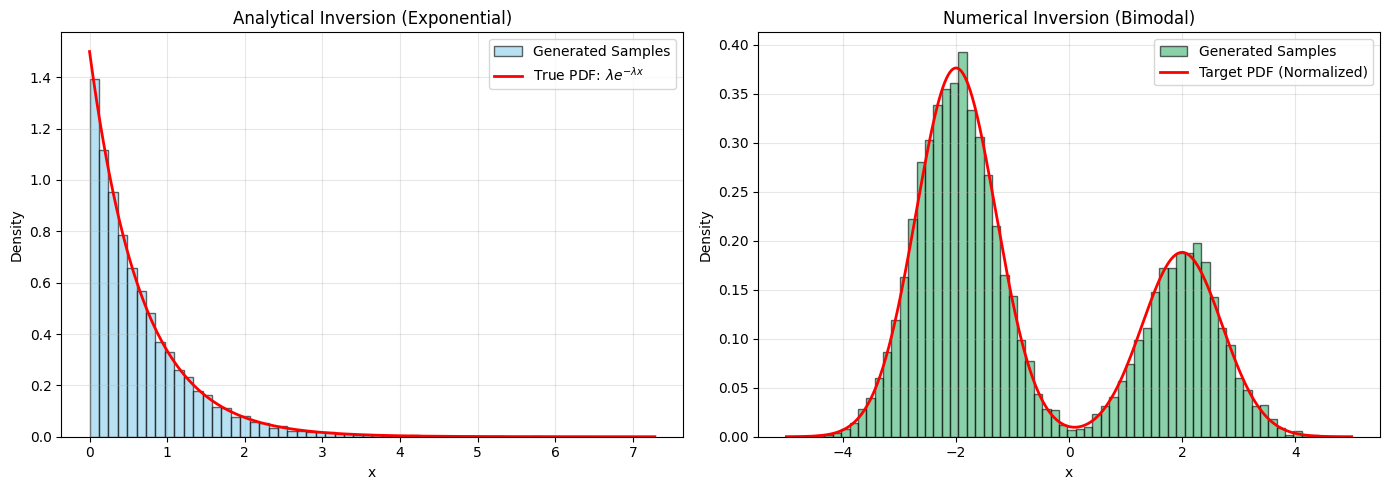

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(samples_exp, bins=60, density=True, 
             alpha=0.6, color='skyblue', edgecolor='black', label='Generated Samples')
x_exp = np.linspace(0, np.max(samples_exp), 500)
pdf_exp_true = lam * np.exp(-lam * x_exp)
axes[0].plot(x_exp, pdf_exp_true, 'r-', lw=2, label=r'True PDF: $\lambda e^{-\lambda x}$')
axes[0].set_title('Analytical Inversion (Exponential)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(samples_custom, bins=60, density=True, 
             alpha=0.6, color='mediumseagreen', edgecolor='black', label='Generated Samples')
pdf_area = np.trapz(pdf_grid, x_grid)
axes[1].plot(x_grid, pdf_grid / pdf_area, 'r-', lw=2, label='Target PDF (Normalized)')
axes[1].set_title('Numerical Inversion (Bimodal)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Outputs/Random_Number_Generation/Inversion_Method.png')
plt.show()

---

### Box–Muller Method:

$$
U_1 \sim Unif(0,1) \qquad U_2 \sim Unif(0,1)
$$

$$
X_1 = \sqrt{-2\ln(U_1)} \cdot \cos(2\pi U_2)  \qquad  X_2 = \sqrt{-2\ln(U_1)} \cdot \sin(2\pi U_2)
$$

$$
\begin{pmatrix} X_1 \\ X_2 \end{pmatrix} \sim \mathcal{N}\left(\begin{pmatrix} 0 \\ 0 \end{pmatrix}, \mathbf{I}\right)
$$

In [6]:
def Box_Muller(size):
    u = np.random.uniform(low=1e-10, high=1, size=(size, 2))
    u1, u2 = u[:, 0], u[:, 1]

    n1 = np.sqrt(-2 * np.log(u1)) * np.cos(2*np.pi * u2)
    n2 = np.sqrt(-2 * np.log(u1)) * np.sin(2*np.pi * u2)

    return np.column_stack((n1, n2)), u

In [7]:
array, unif = Box_Muller(1300)
array

array([[-1.50229589,  0.34673859],
       [ 0.65841859, -2.46874111],
       [ 0.23650687, -1.1679014 ],
       ...,
       [-0.79230626,  0.12537773],
       [-0.59605026, -0.24249212],
       [ 2.13325128, -1.14014485]])

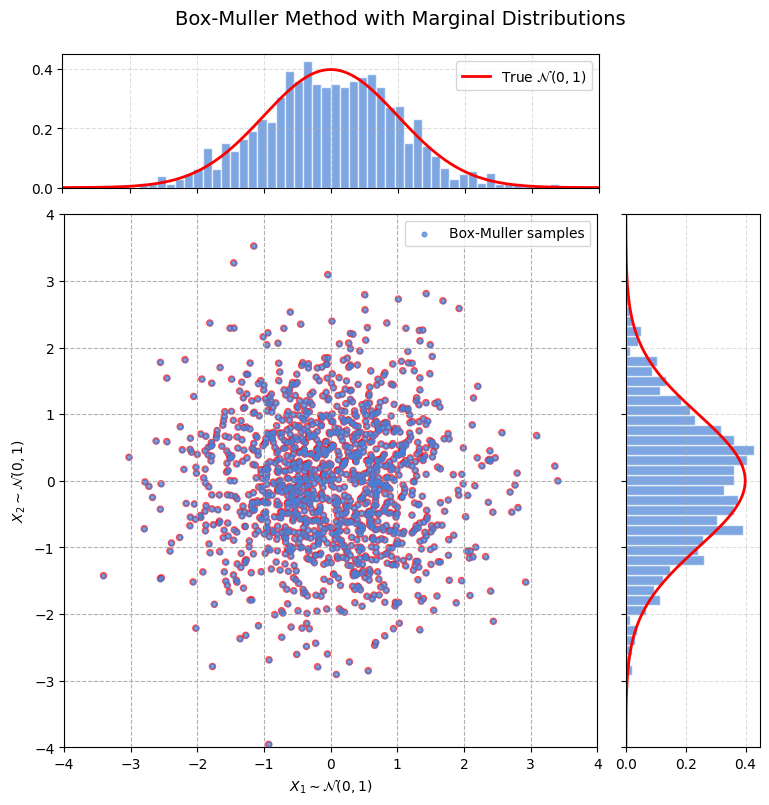

In [8]:
x_norm = np.linspace(-4, 4, 300)
pdf_norm = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * x_norm**2)

fig = plt.figure(figsize=(9, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], 
                      wspace=0.08, hspace=0.08)

ax_main  = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.scatter(array[:, 0], array[:, 1], c="#4780D7", s=11, alpha=0.7, label='Box-Muller samples', zorder=3)
ax_main.scatter(array[:, 0], array[:, 1], s=15, alpha=0.7, linewidths=1.5, facecolors='none', edgecolors='r', zorder=1)
ax_main.set_xlim([-4, 4])
ax_main.set_ylim([-4, 4])
ax_main.grid(True, linestyle='--', zorder=0)
ax_main.set_aspect('equal')
ax_main.set_xlabel('$X_1 \\sim \\mathcal{N}(0,1)$')
ax_main.set_ylabel('$X_2 \\sim \\mathcal{N}(0,1)$')
ax_main.legend(loc='upper right')

ax_histx.hist(array[:, 0], bins=50, density=True, color="#4780D7", alpha=0.7, edgecolor='white')
ax_histx.plot(x_norm, pdf_norm, color='red', linewidth=2, label=r'True $\mathcal{N}(0,1)$')
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.grid(True, linestyle='--', alpha=0.4)
ax_histx.legend(loc='upper right')

ax_histy.hist(array[:, 1], bins=50, density=True, color="#4780D7", alpha=0.7, edgecolor='white', orientation='horizontal')
ax_histy.plot(pdf_norm, x_norm, color='red', linewidth=2)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Box-Muller Method with Marginal Distributions', fontsize=14, y=0.93)
plt.savefig('Outputs/Random_Number_Generation/Box_Muller_Marginals.png', bbox_inches='tight')
plt.show()

---

### Rejection Sampling:

$$
Y \sim g(y) \qquad U \sim \text{Unif}(0,1)
$$

$$
\text{Accept } X = Y \quad \text{if } U \le \frac{f(Y)}{M \cdot g(Y)}, \qquad \text{else repeat}
$$

$$
X \sim f(x) \qquad \text{where } M \cdot g(x) \ge f(x) \ \forall x
$$

In [ ]:
def rejection_sampling(pdf, xmin, xmax, M, size):
    
    samples = []
    while len(samples) < size:

        y = np.random.uniform(xmin, xmax)     # Covers all functions - it might not be efficient though
        alpha = pdf(y) / M
        u = np.random.uniform(0, 1)
        if u <= alpha:
            samples.append(y)
            
    return np.array(samples)

$$f(x) = \left( e^{-\frac{x^2}{13}} \cos(2x) \right)^2$$

In [117]:
def pdf_rj(x):
    return (np.exp(-x**2 / 13) * np.cos(2*x))**2

def pdf_rj_normalized(pdf_rj, x_grid):
    f = pdf_rj(x_grid)
    c = np.trapz(f, x_grid)
    return f/c

In [118]:
x_min, x_max = -11, 11
x_grid = np.linspace(x_min, x_max, 1000)
M = np.max(pdf_rj(x_grid))

rejection_samples = rejection_sampling(pdf_rj, x_min, x_max, M, 7300)

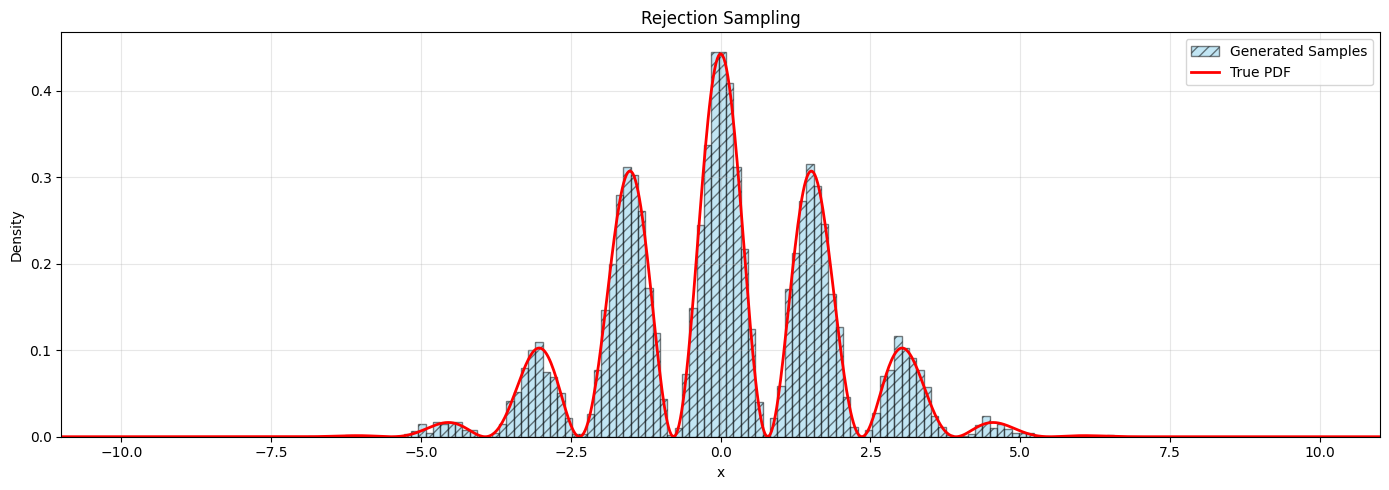

In [120]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.hist(rejection_samples, bins=110, density=True, 
        alpha=0.5, color='skyblue', edgecolor=(0, 0, 0, 0.1), hatch='///', label='Generated Samples')
ax.plot(x_grid, pdf_rj_normalized(pdf_rj, x_grid), 'r-', lw=2, label=r'True PDF')

ax.set_xlim([x_min, x_max])
ax.set_title('Rejection Sampling')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('Outputs/Random_Number_Generation/Rejection_Sampling.png')
plt.show()

---